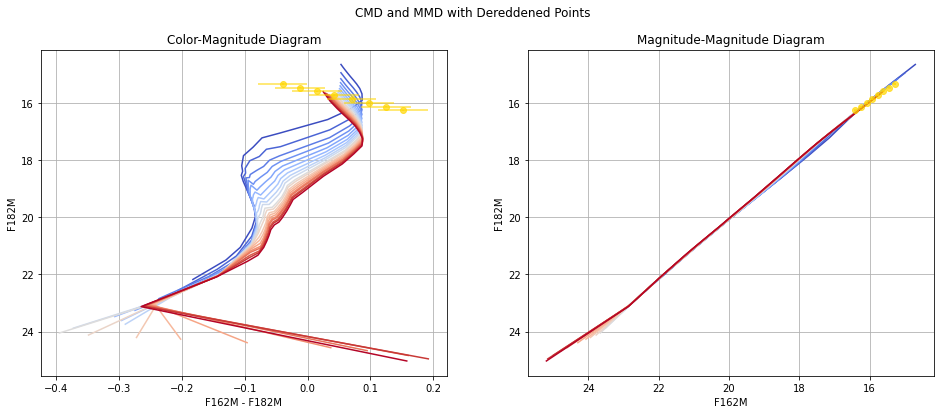

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from spisea import synthetic, evolution, atmospheres, reddening
from spisea.imf import imf, multiplicity
from matplotlib.colors import LogNorm
import csv

# Paths for isochrones and output
iso_dir = 'isochrones/'
output_dir = 'output_diagrams/'
os.makedirs(output_dir, exist_ok=True)

# Estimation variables
star_index = 0  # Set which star in the CSV to analyze

# Define static isochrone parameters
dist = 4500  # Distance in parsecs
evo_model = evolution.Baraffe15()
atm_func = atmospheres.get_merged_atmosphere
red_law = reddening.RedLawCardelli(3.1)
filt_list = ['jwst,F162M', 'jwst,F182M']
filters = ['m_jwst_F162M', 'm_jwst_F182M']
metallicity = 0
level_ages = np.linspace(1, 10, 19) * 1e6  # Define age array
log_age_arr = np.log10(level_ages)

# Load sample magnitudes and errors from CSV
sample_mags = []
sample_errs = []
with open('./aabha-sno46.csv', mode='r') as file:
    csvFile = csv.reader(file)
    next(csvFile)  # Skip header row
    for lines in csvFile:
        mags = [float(lines[i]) for i in range(1, len(lines), 2)]
        errs = [float(lines[i]) for i in range(2, len(lines), 2)]
        sample_mags.append(mags)
        sample_errs.append(errs)

# Function to generate isochrone grid
def generate_isochrones(AKs):
    return np.array([
        synthetic.IsochronePhot(log_age, AKs, dist, metallicity=metallicity,
                                evo_model=evo_model, atm_func=atm_func,
                                red_law=red_law, filters=filt_list,
                                iso_dir=iso_dir)
        for log_age in log_age_arr
    ])

# Generate isochrone grid for AKs = 0 (no extinction)
isochrone_AKs_00 = generate_isochrones(0.0)

# Wavelength dictionary for JWST filters
filter_wavelengths = {
    "m_jwst_F162M": 1.62,
    "m_jwst_F182M": 1.82,
    "m_jwst_F200W": 2.00,
    "m_jwst_F356M": 3.56,
    "m_jwst_F405N": 4.05
}

# Extract magnitudes and errors for the selected star
m162, m182 = sample_mags[star_index][:2]  # Magnitudes
err162, err182 = sample_errs[star_index][:2]  # Errors

# Define AKs range for dereddening
AKs_values = np.arange(0.7, 1.5, 0.1)  # Adjustable range and step size

# Store dereddened magnitudes
dereddened_mags = []
for AKs_ref in AKs_values:
    m162_dered = m162 - red_law.Cardelli89(filter_wavelengths["m_jwst_F162M"], AKs_ref)
    m182_dered = m182 - red_law.Cardelli89(filter_wavelengths["m_jwst_F182M"], AKs_ref)
    dereddened_mags.append((m162_dered, m182_dered))

# Compute errors in color (m162 - m182) and in F182M magnitude
color_err = np.sqrt(err162**2 + err182**2)  # Propagate errors in color
mag_err = err182  # Vertical error is just the F182M error

# Plot function with dereddened points
def plot_cmd_mmd_with_dereddening(isochrone_grid, dered_mags, ref_errs, title, filename):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    cmap = plt.get_cmap("coolwarm")

    # Plot Color-Magnitude Diagram (CMD)
    for i, instance in enumerate(isochrone_grid):
        color = cmap(i / (len(isochrone_grid) - 1))
        ax1.plot(instance.points["m_jwst_F162M"] - instance.points["m_jwst_F182M"],
                 instance.points["m_jwst_F182M"], color=color)
    
    for i, (m162_d, m182_d) in enumerate(dered_mags):
        ax1.errorbar(m162_d - m182_d, m182_d, xerr=ref_errs[0], yerr=ref_errs[1],
                     fmt='o', color='gold', alpha=0.7)
    
    ax1.set_xlabel("F162M - F182M")
    ax1.set_ylabel("F182M")
    ax1.invert_yaxis()
    ax1.grid(True)
    ax1.set_title("Color-Magnitude Diagram")

    # Plot Magnitude-Magnitude Diagram (MMD)
    for i, instance in enumerate(isochrone_grid):
        color = cmap(i / (len(isochrone_grid) - 1))
        ax2.plot(instance.points["m_jwst_F162M"], instance.points["m_jwst_F182M"], color=color)
    
    for i, (m162_d, m182_d) in enumerate(dered_mags):
        ax2.errorbar(m162_d, m182_d, xerr=ref_errs[0], yerr=ref_errs[1],
                     fmt='o', color='gold', alpha=0.7)
    
    ax2.set_xlabel("F162M")
    ax2.set_ylabel("F182M")
    ax2.invert_xaxis()
    ax2.invert_yaxis()
    ax2.grid(True)
    ax2.set_title("Magnitude-Magnitude Diagram")

    plt.suptitle(title)
    # plt.savefig(os.path.join(output_dir, filename))
    plt.show()

# Plot CMD and MMD with dereddened points
plot_cmd_mmd_with_dereddening(isochrone_AKs_00, dereddened_mags, [color_err, mag_err],
                              "CMD and MMD with Dereddened Points", "CMD_MMD_DEREDDENED.png")


In [ ]:
filt_list = ['jwst,F162M', 'jwst,F182M', 'jwst,F200W']
filters = ['m_jwst_F162M', 'm_jwst_F182M', 'm_jwst_F200W']

# Load sample magnitudes and errors
sample_mags, sample_errors = [], []

with open('./aabha-sno46.csv', mode='r') as file:
    csvFile = csv.reader(file)
    next(csvFile)  # Skip header row
    for line in csvFile:
        sample_mags.append([float(line[1]), float(line[3]), float(line[5])])  # Extract F162M, F182M, F200W
        sample_errors.append([float(line[2]), float(line[4]), float(line[6])])  # Extract corresponding errors

sample_mags = np.array(sample_mags)
sample_errors = np.array(sample_errors)

# Chi-square function accounting for errors
def chi_square_with_errors(iso_grid, obs_mags, obs_errors):
    DOF = len(obs_mags) - 1  # Degrees of freedom: num filters - 1
    chi_square_grid = np.zeros((len(iso_grid), len(iso_grid[0].points)))
    
    for i, iso in enumerate(iso_grid):
        for j, star in enumerate(iso.points):
            chi_sq = sum(
                ((obs_mags[k] - star[filters[k]]) ** 2) / max(obs_errors[k] ** 2, 1e-3)  # Avoid zero division
                for k in range(len(obs_mags))
            )
            chi_square_grid[i, j] = chi_sq / DOF  # Compute reduced chi-square
    
    return chi_square_grid

for AKs in AKs_values:
    # Ensure directories exist
    os.makedirs(iso_dir, exist_ok=True)

    # Clear previous isochrones
    for file in os.listdir(iso_dir):
        os.remove(os.path.join(iso_dir, file))

    # Generate isochrone grid
    instances = np.array([
        synthetic.IsochronePhot(log_age, AKs, dist, metallicity=metallicity,
                                evo_model=evo_model, atm_func=atm_func,
                                red_law=red_law, filters=filt_list,
                                iso_dir=iso_dir)
        for log_age in log_age_arr
    ])

    # Compute chi-square values for each point, accounting for errors
    chi_square_values = chi_square_with_errors(instances, sample_mags[0], sample_errors[0])

    # Extract mass values for each isochrone
    masses = np.array([[star['mass'] for star in iso.points] for iso in instances])

    # Plotting
    fig, ax = plt.subplots(figsize=(10, 8))
    norm = LogNorm(vmin=max(np.min(chi_square_values), 1e-3), vmax=np.max(chi_square_values))
    cmap = plt.get_cmap('coolwarm')

    # Scatter plot with chi-square gradient
    sc = ax.scatter(
        np.repeat(level_ages, chi_square_values.shape[1]), 
        masses.flatten(), c=chi_square_values.flatten(), cmap=cmap, norm=norm, s=50, edgecolor='k', linewidth=0.5
    )
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Chi-Squared Value')

    # Apply logarithmic scale to y-axis
    ax.set_yscale('log')

    # Contour plot for chi-square threshold
    contour = plt.contour(level_ages, masses[0], chi_square_values.T, levels=[5.991], colors=['black'], linewidths=2.5)
    ax.clabel(contour, inline=True, fontsize=12)

    # Labels and styling
    ax.set_xlabel('Age (years)')
    ax.set_ylabel('Mass (M☉)')
    ax.set_title(f'Age-Mass Diagram with Chi-Squared Contouring (AKs = {AKs})')
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)

    # Axis padding
    x_padding = 0.1 * (level_ages[-1] - level_ages[0])
    y_padding_factor = 0.1
    ax.set_xlim(level_ages[0] - x_padding, level_ages[-1] + x_padding)
    ax.set_ylim(np.min(masses) * (1 - y_padding_factor), np.max(masses) * (1 + y_padding_factor))

    # plt.show()
    plt.savefig(f"{output_dir}/chi_squared_AKs_{AKs:.1f}.png", facecolor='white')
    plt.close()

Isochrone generation took 1.252667 s.
Making photometry for isochrone: log(t) = 6.00  AKs = 0.70  dist = 4500
     Starting at:  2025-03-18 05:43:19.712800   Usually takes ~5 minutes
Starting filter: jwst,F162M   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F162M = 23.11
Starting filter: jwst,F182M   Elapsed time: 0.67 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F182M = 23.10
Starting filter: jwst,F200W   Elapsed time: 1.34 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F200W = 22.85
      Time taken: 2.00 seconds
Isochrone generation took 1.162530 s.
Making photometry for isochrone: log(t) = 6.18  AKs = 0.70  dist = 4500
     Starting at:  2025-03-18 05:43:22.889849   Usually takes ~5 minutes
Starting filter: jwst,F162M   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2292 K  m_jwst_F162M = 23.47
Starting filter: jwst,F182M   Elapsed time: 0.6

Starting filter: jwst,F200W   Elapsed time: 1.34 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  1814 K  m_jwst_F200W = 24.78
      Time taken: 2.02 seconds
Changing to logg=5.00 for T=  1773 logg=4.01
Isochrone generation took 1.162475 s.
Making photometry for isochrone: log(t) = 6.88  AKs = 0.70  dist = 4500
     Starting at:  2025-03-18 05:44:01.488919   Usually takes ~5 minutes
Starting filter: jwst,F162M   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  1773 K  m_jwst_F162M = 25.40
Starting filter: jwst,F182M   Elapsed time: 0.66 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  1773 K  m_jwst_F182M = 25.31
Starting filter: jwst,F200W   Elapsed time: 1.34 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  1773 K  m_jwst_F200W = 24.89
      Time taken: 2.05 seconds
Changing to logg=5.00 for T=  1711 logg=4.02
Isochrone generation took 1.128456 s.
Making photometry for isochrone: log(t) = 6.90  AKs = 0.70  dist = 4500

Starting filter: jwst,F182M   Elapsed time: 0.67 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2052 K  m_jwst_F182M = 24.67
Starting filter: jwst,F200W   Elapsed time: 1.33 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2052 K  m_jwst_F200W = 24.33
      Time taken: 2.00 seconds
Isochrone generation took 1.137161 s.
Making photometry for isochrone: log(t) = 6.65  AKs = 0.80  dist = 4500
     Starting at:  2025-03-18 05:44:43.042816   Usually takes ~5 minutes
Starting filter: jwst,F162M   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2011 K  m_jwst_F162M = 24.72
Starting filter: jwst,F182M   Elapsed time: 0.67 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2011 K  m_jwst_F182M = 24.80
Starting filter: jwst,F200W   Elapsed time: 1.33 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2011 K  m_jwst_F200W = 24.45
      Time taken: 2.01 seconds
Changing to logg=5.00 for T=  1960 logg=3.95
Isochrone gener

Starting filter: jwst,F200W   Elapsed time: 1.31 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  1571 K  m_jwst_F200W = 25.63
      Time taken: 1.97 seconds
Isochrone generation took 1.159744 s.
Making photometry for isochrone: log(t) = 6.00  AKs = 0.90  dist = 4500
     Starting at:  2025-03-18 05:45:21.336536   Usually takes ~5 minutes
Starting filter: jwst,F162M   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F162M = 23.42
Starting filter: jwst,F182M   Elapsed time: 0.65 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F182M = 23.36
Starting filter: jwst,F200W   Elapsed time: 1.35 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F200W = 23.08
      Time taken: 2.02 seconds
Isochrone generation took 1.158895 s.
Making photometry for isochrone: log(t) = 6.18  AKs = 0.90  dist = 4500
     Starting at:  2025-03-18 05:45:24.532514   Usually takes ~5 minutes
Starting filter:

Starting filter: jwst,F182M   Elapsed time: 0.70 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  1814 K  m_jwst_F182M = 25.45
Starting filter: jwst,F200W   Elapsed time: 1.37 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  1814 K  m_jwst_F200W = 25.01
      Time taken: 2.06 seconds
Changing to logg=5.00 for T=  1773 logg=4.01
Isochrone generation took 1.191250 s.
Making photometry for isochrone: log(t) = 6.88  AKs = 0.90  dist = 4500
     Starting at:  2025-03-18 05:46:03.005258   Usually takes ~5 minutes
Starting filter: jwst,F162M   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  1773 K  m_jwst_F162M = 25.72
Starting filter: jwst,F182M   Elapsed time: 0.67 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  1773 K  m_jwst_F182M = 25.57
Starting filter: jwst,F200W   Elapsed time: 1.33 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  1773 K  m_jwst_F200W = 25.11
      Time taken: 2.01 seconds
Changing to log

Starting filter: jwst,F182M   Elapsed time: 0.67 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2052 K  m_jwst_F182M = 24.94
Starting filter: jwst,F200W   Elapsed time: 1.35 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2052 K  m_jwst_F200W = 24.56
      Time taken: 2.03 seconds
Isochrone generation took 1.144572 s.
Making photometry for isochrone: log(t) = 6.65  AKs = 1.00  dist = 4500
     Starting at:  2025-03-18 05:46:45.156218   Usually takes ~5 minutes
Starting filter: jwst,F162M   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2011 K  m_jwst_F162M = 25.04
Starting filter: jwst,F182M   Elapsed time: 0.68 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2011 K  m_jwst_F182M = 25.06
Starting filter: jwst,F200W   Elapsed time: 1.35 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2011 K  m_jwst_F200W = 24.68
      Time taken: 2.02 seconds
Changing to logg=5.00 for T=  1960 logg=3.95
Isochrone gener

Starting filter: jwst,F200W   Elapsed time: 1.31 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  1571 K  m_jwst_F200W = 25.86
      Time taken: 1.97 seconds
Isochrone generation took 1.210808 s.
Making photometry for isochrone: log(t) = 6.00  AKs = 1.10  dist = 4500
     Starting at:  2025-03-18 05:47:23.854012   Usually takes ~5 minutes
Starting filter: jwst,F162M   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F162M = 23.74
Starting filter: jwst,F182M   Elapsed time: 0.66 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F182M = 23.63
Starting filter: jwst,F200W   Elapsed time: 1.32 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F200W = 23.31
      Time taken: 1.98 seconds
Isochrone generation took 1.149629 s.
Making photometry for isochrone: log(t) = 6.18  AKs = 1.10  dist = 4500
     Starting at:  2025-03-18 05:47:27.000549   Usually takes ~5 minutes
Starting filter:

Starting filter: jwst,F182M   Elapsed time: 0.70 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  1814 K  m_jwst_F182M = 25.71
Starting filter: jwst,F200W   Elapsed time: 1.42 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  1814 K  m_jwst_F200W = 25.23
      Time taken: 2.10 seconds
Changing to logg=5.00 for T=  1773 logg=4.01
Isochrone generation took 1.170105 s.
Making photometry for isochrone: log(t) = 6.88  AKs = 1.10  dist = 4500
     Starting at:  2025-03-18 05:48:05.567163   Usually takes ~5 minutes
Starting filter: jwst,F162M   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  1773 K  m_jwst_F162M = 26.04
Starting filter: jwst,F182M   Elapsed time: 0.68 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  1773 K  m_jwst_F182M = 25.83
Starting filter: jwst,F200W   Elapsed time: 1.36 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  1773 K  m_jwst_F200W = 25.34
      Time taken: 2.05 seconds
Changing to log

Starting filter: jwst,F182M   Elapsed time: 0.68 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2052 K  m_jwst_F182M = 25.20
Starting filter: jwst,F200W   Elapsed time: 1.34 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2052 K  m_jwst_F200W = 24.78
      Time taken: 2.03 seconds
Isochrone generation took 1.201788 s.
Making photometry for isochrone: log(t) = 6.65  AKs = 1.20  dist = 4500
     Starting at:  2025-03-18 05:48:47.989527   Usually takes ~5 minutes
Starting filter: jwst,F162M   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2011 K  m_jwst_F162M = 25.35
Starting filter: jwst,F182M   Elapsed time: 0.82 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2011 K  m_jwst_F182M = 25.33
Starting filter: jwst,F200W   Elapsed time: 1.62 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2011 K  m_jwst_F200W = 24.90
      Time taken: 2.40 seconds
Changing to logg=5.00 for T=  1960 logg=3.95
Isochrone gener

Starting filter: jwst,F200W   Elapsed time: 1.58 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  1571 K  m_jwst_F200W = 26.09
      Time taken: 2.34 seconds
Isochrone generation took 1.249689 s.
Making photometry for isochrone: log(t) = 6.00  AKs = 1.30  dist = 4500
     Starting at:  2025-03-18 05:49:32.221304   Usually takes ~5 minutes
Starting filter: jwst,F162M   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F162M = 24.06
Starting filter: jwst,F182M   Elapsed time: 0.77 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F182M = 23.89
Starting filter: jwst,F200W   Elapsed time: 1.53 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F200W = 23.54
      Time taken: 2.29 seconds
Isochrone generation took 1.215403 s.
Making photometry for isochrone: log(t) = 6.18  AKs = 1.30  dist = 4500
     Starting at:  2025-03-18 05:49:35.741366   Usually takes ~5 minutes
Starting filter: